In [1]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

---

#### Loading the dataset

In [2]:
data = load_dataset('jxie/flickr8k')

README.md:   0%|          | 0.00/687 [00:00<?, ?B/s]

data/train-00000-of-00002-2f8f6bfa852eac(…): reconstructing file:   0%|          |  0.00B /  414MB            

data/train-00000-of-00002-2f8f6bfa852eac(…): downloading bytes:           |  0.00B            

data/train-00001-of-00002-2173151d8cd6c7(…): reconstructing file:   0%|          |  0.00B /  414MB            

data/train-00001-of-00002-2173151d8cd6c7(…): downloading bytes:           |  0.00B            

...

data/test-00000-of-00001-42a2661d12c73e4(…): reconstructing file:   0%|          |  0.00B /  137MB            

data/test-00000-of-00001-42a2661d12c73e4(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [3]:
data.shape

{'train': (6000, 6), 'validation': (1000, 6), 'test': (1000, 6)}

In [4]:
print(data['train'])

Dataset({
    features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
    num_rows: 6000
})


In [5]:
data['train'][0]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x399>,
 'caption_0': 'A black dog is running after a white dog in the snow .',
 'caption_1': 'Black dog chasing brown dog through snow',
 'caption_2': 'Two dogs chase each other across the snowy ground .',
 'caption_3': 'Two dogs play together in the snow .',
 'caption_4': 'Two dogs running through a low lying body of water .'}

In [6]:
train = data['train']
test = data['test']
validation = data['validation']

In [7]:
test[0]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x335>,
 'caption_0': 'The dogs are in the snow in front of a fence .',
 'caption_1': 'The dogs play on the snow .',
 'caption_2': 'Two brown dogs playfully fight in the snow .',
 'caption_3': 'Two brown dogs wrestle in the snow .',
 'caption_4': 'Two dogs playing in the snow .'}

#### Visualizing the data

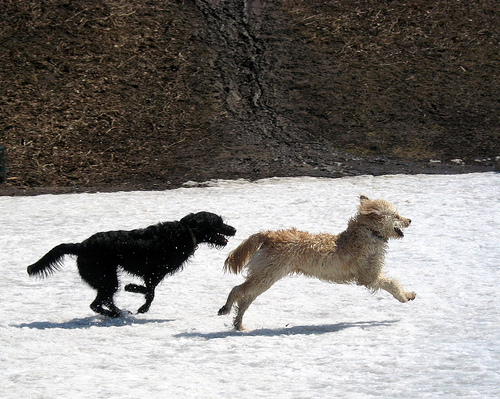

In [8]:
display(train[0]['image'])


================================================== IMG 1 ==================================================
A black dog is running after a white dog in the snow .
Black dog chasing brown dog through snow
Two dogs chase each other across the snowy ground .
Two dogs play together in the snow .
Two dogs running through a low lying body of water .



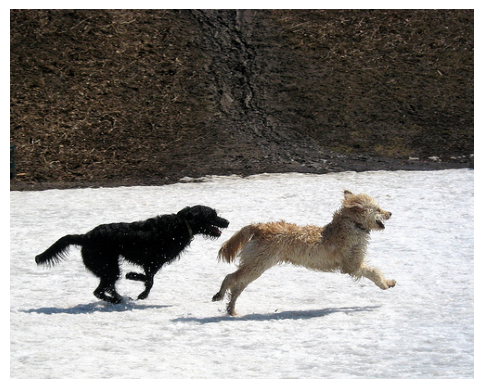


================================================== IMG 2 ==================================================
A little baby plays croquet .
A little girl plays croquet next to a truck .
The child is playing croquette by the truck .
The kid is in front of a car with a put and a ball .
The little boy is playing with a croquet hammer and ball beside the car .



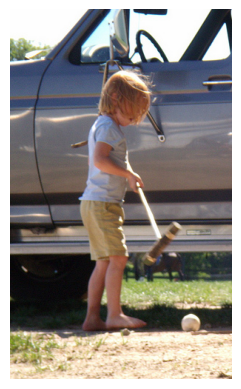


================================================== IMG 3 ==================================================
A brown dog in the snow has something hot pink in its mouth .
A brown dog in the snow holding a pink hat .
A brown dog is holding a pink shirt in the snow .
A dog is carrying something pink in its mouth while walking through the snow .
A dog with something pink in its mouth is looking forward .



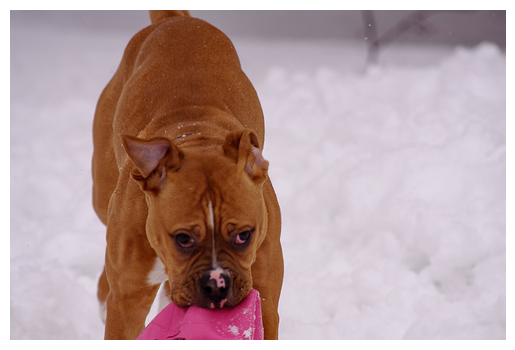


================================================== IMG 4 ==================================================
A brown dog is running along a beach .
A brown dog wearing a black collar running across the beach .
A dog walks on the sand near the water .
Brown dog running on the beach .
The large brown dog is running on the beach by the ocean .



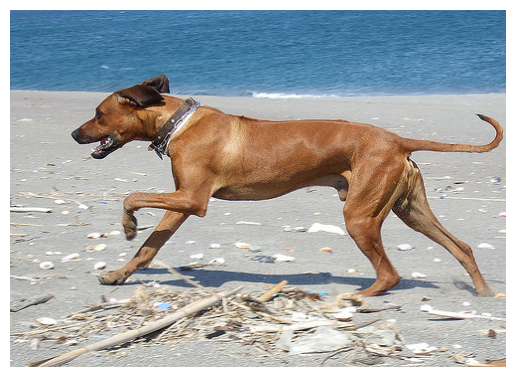


================================================== IMG 5 ==================================================
A black and white dog with a red Frisbee standing on a sandy beach .
A dog drops a red disc on a beach .
A dog with a red Frisbee flying in the air .
Dog catching a red Frisbee .
The black dog is dropping a red disc on a beach .



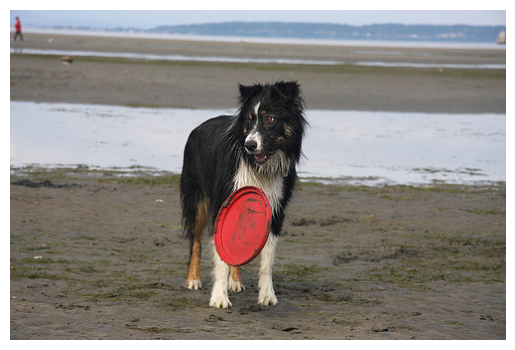

In [9]:
import matplotlib.pyplot as plt

def show(num):
    for i in range(5):
        print(train[num][f'caption_{i}'])

    print()
    plt.imshow(train[num]['image'])
    plt.axis('off')
    plt.show()


for i in range(5):
    print()
    print("=" * 50, f'IMG {i+1}', "=" * 50)
    show(i)

#### Image preprocessing

In [10]:
train

Dataset({
    features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
    num_rows: 6000
})

In [11]:
for i in ['train', 'validation', 'test']:
    # Remove 'image' column so it only converts text to a DataFrame
    df = data[i].remove_columns('image').to_pandas()
    
    print(f"=== Null values in {i} ===")
    print(df.isnull().sum())
    print()

=== Null values in train ===
caption_0    0
caption_1    0
caption_2    0
caption_3    0
caption_4    0
dtype: int64

=== Null values in validation ===
caption_0    0
caption_1    0
caption_2    0
caption_3    0
caption_4    0
dtype: int64

=== Null values in test ===
caption_0    0
caption_1    0
caption_2    0
caption_3    0
caption_4    0
dtype: int64



---

#### Converting into pandas dataframe

In [12]:
train = pd.DataFrame({
    'image': train['image'],
    'caption_0': train['caption_0'],
    'caption_1': train['caption_1'],
    'caption_2': train['caption_2'],
    'caption_3': train['caption_3'],
    'caption_4': train['caption_4'],
})

test = pd.DataFrame({
    'image': test['image'],
    'caption_0': test['caption_0'],
    'caption_1': test['caption_1'],
    'caption_2': test['caption_2'],
    'caption_3': test['caption_3'],
    'caption_4': test['caption_4'],
})

validation = pd.DataFrame({
    'image': validation['image'],
    'caption_0': validation['caption_0'],
    'caption_1': validation['caption_1'],
    'caption_2': validation['caption_2'],
    'caption_3': validation['caption_3'],
    'caption_4': validation['caption_4'],
})


In [13]:
print(train.shape)
print(test.shape)
print(validation.shape)
print()
train.sample(5)

(6000, 6)
(1000, 6)
(1000, 6)



,image,caption_0,caption_1,caption_2,caption_3,caption_4
535,<PIL.JpegImagePlugin.JpegImageFile image mode=...,A group of bicyclists getting ready for a ride .,A group of cyclists is pausing nearby a green ...,A group of men are standing around and drinkin...,A group of men chat and drink water from water...,Men in athletic clothing stand near bicycles .
4263,<PIL.JpegImagePlugin.JpegImageFile image mode=...,A bald man dribbles a basketball while wearing...,"Man playing basketball , jersey number 5 .",Number five plays basketball for Miami .,The basketball player is wearing orange sneake...,The number five Miami player dribbles down the...
2142,<PIL.JpegImagePlugin.JpegImageFile image mode=...,A bicyclist riding on a city street .,A woman in a blue helmet and brown shorts ride...,A woman is riding a blue bike .,A woman is riding her bicycle in traffic,A woman wearing a blue helmet rides her bicycl...
461,<PIL.JpegImagePlugin.JpegImageFile image mode=...,A girl holds a blue balloon as she walks .,A girl in red shirt holds a green balloon in a...,a Japanese girl carries a green balloon .,An Asian boy in a red shirt holds onto an aqua...,The girl is holding a blue balloon on a busy s...
726,<PIL.JpegImagePlugin.JpegImageFile image mode=...,A climber wearing a blue helmet and headlamp i...,A man climbs a rocky wall .,a rock climber climbs a large rock .,A woman in purple snakeskin pants climbs a rock .,Person with blue helmet and purple pants is ro...


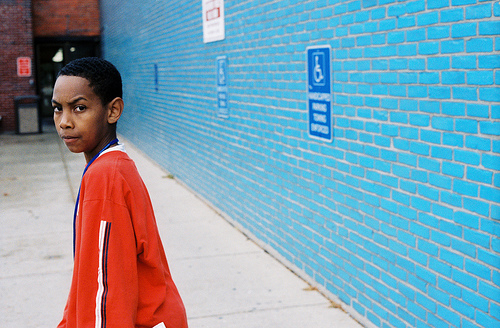

a boy in a red shirt , in front of a long blue wall , raises his eyebrow at the camera
A boy in a red shirt with stripes standing near a blue , brick wall with handicap signs .
An African American boy stands in front of a blue building in the handicapped space .
The boy in the orange shirt looks backwards .
The boy in the red shirt is next to a blue wall .


In [14]:
display(train['image'][20])
print(train['caption_0'][20])
print(train['caption_1'][20])
print(train['caption_2'][20])
print(train['caption_3'][20])
print(train['caption_4'][20])

---

#### Image preprocessing (converting img into vector)

In [15]:
# importing tensorflow

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential

In [16]:
# converting PIL img into a preprocessed tensor
def preprocess_img(img, augment=False):
    img = img.convert('RGB')                             # converting imgs into rgb
    img = keras.preprocessing.image.img_to_array(img)        # converting rgb img into tensor
    img = tf.image.resize(img, (224,224))                    # resizing the img
    img = img / 255.0                                        # rescaling the img

    return img

I0000 00:00:1791646118.263638      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13622 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791646118.266684      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Original Image size:     (500, 399) (Width, Height)
Preprocessed Tensor shape: (224, 224, 3) (Height, Width, Channels)
Min pixel value:         0.0
Max pixel value:         1.0


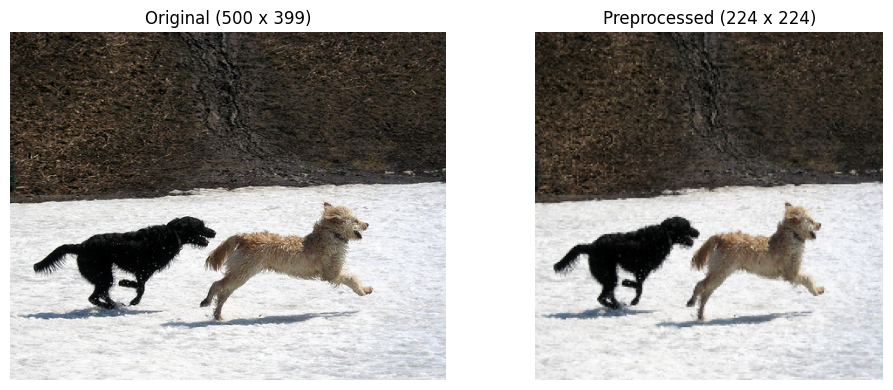

In [17]:
# CHECKING IMAGE BEFORE AND AFTER PREPROCESSING

# Use data['train'] directly:
temp = data['train'][0]['image']

temp_tensor = preprocess_img(temp)

print("Original Image size:    ", temp.size, "(Width, Height)")
print("Preprocessed Tensor shape:", temp_tensor.shape, "(Height, Width, Channels)")
print("Min pixel value:        ", float(tf.reduce_min(temp_tensor)))
print("Max pixel value:        ", float(tf.reduce_max(temp_tensor)))

# Plot
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(temp)
plt.title(f"Original ({temp.size[0]} x {temp.size[1]})")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(temp_tensor.numpy())
plt.title(f"Preprocessed ({temp_tensor.shape[0]} x {temp_tensor.shape[1]})")
plt.axis('off')

plt.tight_layout()
plt.show()

---

#### Converting the images into numpy array

In [19]:
# CONVERTING INTO NUMPY ARRAY
# converting into numpy arra is indeed necessary bcoz img processing model will only read numpy array
# since these are 3D tensors so instead of np.array, we have to use np.stack

train_processed = np.stack(train['image'].map(preprocess_img))
test_processed = np.stack(test['image'].map(preprocess_img))
validation_processed = np.stack(validation['image'].map(preprocess_img))

In [18]:
# checking tensor shapes

print(preprocess_img(train['image'][0]).shape)
print()
print(type(preprocess_img(train['image'][0])))
print()
preprocess_img(train['image'][0])                                           # 3 features in the tensor below represents the 3 color channels (red, green, blue)

(224, 224, 3)

<class 'tensorflow.python.framework.ops.EagerTensor'>



<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
array([[[0.24966627, 0.17949437, 0.18051854],
        [0.10929784, 0.09633718, 0.06254704],
        [0.0869655 , 0.06715086, 0.03924087],
        ...,
        [0.26897097, 0.20998876, 0.194453  ],
        [0.10714143, 0.09459548, 0.05885497],
        [0.21503033, 0.19487146, 0.16994481]],

       [[0.30179393, 0.21109888, 0.17880833],
        [0.29023218, 0.26367134, 0.22444034],
        [0.1377648 , 0.10252102, 0.095475  ],
        ...,
        [0.22000518, 0.1693601 , 0.14007851],
        [0.19569087, 0.12921908, 0.1051382 ],
        [0.12702572, 0.10711124, 0.07806543]],

       [[0.13080797, 0.12111399, 0.08912323],
        [0.13423057, 0.10414205, 0.06263295],
        [0.22367272, 0.18886608, 0.161722  ],
        ...,
        [0.17880517, 0.14959969, 0.11976993],
        [0.24436979, 0.2126296 , 0.17114675],
        [0.24919727, 0.22946428, 0.17267472]],

       ...,

       [[0.91603917, 0.91761535, 0.92041475],
        [0.91

In [20]:
print(type(train_processed))
print(train_processed.shape)
print(test_processed.shape)
print(validation_processed.shape)

<class 'numpy.ndarray'>
(6000, 224, 224, 3)
(1000, 224, 224, 3)
(1000, 224, 224, 3)


In [21]:
train_processed[0].shape

(224, 224, 3)

---

#### Text preprocessing

In [22]:
!pip install cleantext

In [23]:
from cleantext import clean

In [24]:
# text preprocessing
def txt_preprocess(txt):
    txt = clean(
        txt,
        punct=True,                 # removes all the punctuations and symbols in the text
        lowercase=True,
        extra_spaces=True           # removes extra spaces
    )

    return f"<start> {txt} <end>"

In [25]:
txt_preprocess('Hello,     my name is Pradhan ....# @&*#^')

'<start> hello my name is pradhan <end>'

In [30]:
# 1. Extract caption columns to Python lists (avoids the 'image' column & cuDF errors)
caption_cols = [train[f"caption_{j}"].tolist() for j in range(5)]

all_captions, all_imgs = [], []

# 2. Loop image by image, caption by caption
for i in range(len(train)):
    for j in range(5):
        cap = str(caption_cols[j][i])
        all_captions.append(txt_preprocess(cap))
        all_imgs.append(i)

print(len(all_captions))  # Output: 30000
print(len(all_imgs))      # Output: 30000

30000
30000


In [31]:
print(len(caption_cols) )                          # contains five lists, each containing 6000 caption from each captions (for eg, first list will contain 6000 captions from caption_1)
print(len(caption_cols[0]))

5
6000


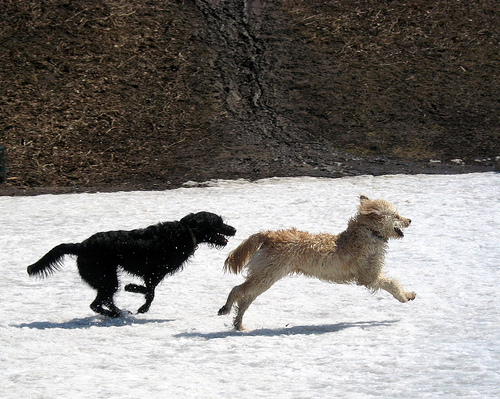

A black dog is running after a white dog in the snow .
A little baby plays croquet .
A brown dog in the snow has something hot pink in its mouth .
A brown dog is running along a beach .
A black and white dog with a red Frisbee standing on a sandy beach .


In [32]:
display(train['image'][0])
print(caption_cols[0][0])
print(caption_cols[0][1])
print(caption_cols[0][2])
print(caption_cols[0][3])
print(caption_cols[0][4])

#### Text vectorization

In [33]:
from tensorflow.keras.layers import TextVectorization

In [34]:
MAX_LEN = max(len(i.split()) for i in all_captions)             # finding the maximum caption length

vectorizer = TextVectorization(
    max_tokens=None,
    output_mode='int',
    output_sequence_length=MAX_LEN
)

In [35]:
txt = 'hello this is god .#&^$*'

vectorizer.adapt(txt)
vocab = vectorizer.get_vocabulary()

print(len(vocab))
print(vocab)

6
['', '[UNK]', np.str_('this'), np.str_('is'), np.str_('hello'), np.str_('god')]


In [36]:
# sending the captions data into the vectorizer
# since LSTM model only takes input of fixed length, that's why we have to fix the input size fixed, hence the code below

vectorizer.adapt(all_captions)                    # sending all the captions to make a vocabulary (like a dictionary containing words) of words to make a vector
vocab = vectorizer.get_vocabulary()

print(f"VOCABULARY SIZE : {len(vocab)} (total num of words the vocab contains)")
print(f"SAMPLE WORDS : \n{vocab[:10]}")

VOCABULARY SIZE : 7632 (total num of words the vocab contains)
SAMPLE WORDS : 
['', '[UNK]', np.str_('a'), np.str_('end'), np.str_('start'), np.str_('in'), np.str_('the'), np.str_('on'), np.str_('is'), np.str_('and')]


---

#### Extracting image features using a pretrained CNN

In [50]:
# Importing image classification pre-trained model (TFViTModel)
import torch as tr
from transformers import ViTImageProcessor, ViTModel

In [53]:
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
model = ViTModel.from_pretrained('google/vit-base-patch16-224') 

# preprocessing the image
img = data['train'][0]['image'].convert('RGB')
inputs = processor(images=img, return_tensors='pt')

# extracting 768 dimentional feature vectors
with tr.no_grad():
    outputs = model(**inputs)

# storing the vectors into an obj
feature_vector = outputs.pooler_output.detach().cpu().numpy()


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [56]:
print(f"EXTRACTED FEATURE VECTOR SHAPE : {feature_vector.shape}")

EXTRACTED FEATURE VECTOR SHAPE : (1, 768)


---

#### Extracting features for all the images (in batches)

In [62]:
if tr.cuda.is_available():
    print('GPU AVAILABLE \nStoring the pre-trained model into the GPU')
    
    model.to('cuda')                  # running the model on gpu
    model.eval()
else:
    print('GPU NOT AVAILABLE')




GPU AVAILABLE 
Storing the pre-trained model into the GPU


In [68]:
def extract_features(batch):
    imgs = [i.convert('RGB') for i in batch['image']]
    inputs = processor(images=imgs, return_tensors='pt').to('cuda')

    with tr.no_grad():
        outputs = model(**inputs)

    return {"feature": outputs.pooler_output.cpu().numpy()}


train_dataset = data['train'].map(extract_features, batched=True, batch_size=64)

image_features = np.array(train_dataset['feature'])



print(image_features.shape)


Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

(6000, 768)


In [69]:
image_features

array([[-3.85617495e-01,  8.03975582e-01, -4.57688004e-01, ...,
         3.27787936e-01,  4.20152545e-01, -5.00131175e-02],
       [ 7.95134187e-01,  4.66526626e-03, -3.64082605e-01, ...,
         1.39488475e-02, -3.42100888e-01,  1.14523992e-01],
       [-2.57454067e-01,  3.90378416e-01,  5.56316376e-01, ...,
         4.22620356e-01,  2.04372257e-02, -1.47558525e-01],
       ...,
       [ 2.74546146e-01,  1.47723898e-01,  5.61547950e-02, ...,
         4.37452734e-01, -5.89657843e-01,  6.44847634e-04],
       [-5.67686595e-02,  6.23603575e-02,  3.70694816e-01, ...,
         6.61915913e-02,  5.61498046e-01, -4.12361830e-01],
       [ 2.43671849e-01, -4.89192963e-01,  7.84234583e-01, ...,
         1.78793162e-01, -6.94929302e-01,  6.69449242e-03]])